<a href="https://colab.research.google.com/github/mevalle/MPCL-CCP/blob/main/experiment_pmlb_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.neural_network import MLPClassifier

Install additional packages!

In [ ]:
!pip install pmlb
!pip install dccp # Necessary for the MPCL library!

from pmlb import fetch_data

Download the MPCL!

In [ ]:
!wget -O MPCL.py https://raw.githubusercontent.com/mevalle/MPCL-CCP/master/MPCL.py
print('MPCL.py downloaded successfully!')

--2026-05-08 12:52:24--  https://raw.githubusercontent.com/mevalle/MPCL-CCP/master/MPCL.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31189 (30K) [text/plain]
Saving to: ‘MPCL.py’

MPCL.py             100%[===================>]  30.46K  --.-KB/s    in 0.005s  

2026-05-08 12:52:24 (6.52 MB/s) - ‘MPCL.py’ saved [31189/31189]

MPCL.py downloaded successfully!


In [ ]:
from MPCL import MPCL_Greedy, MPCL_Adam, MPCL_CCP

# Testing the MPCL models

In [ ]:
X, y = fetch_data('appendicitis', return_X_y=True)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Number of classes: {len(np.unique(y))}, Number of features: {X.shape[1]}, Number of training and test samples: {Xtr.shape[0]}/{Xte.shape[0]}")

Number of classes: 2, Number of features: 7, Number of training and test samples: 74/32


In [ ]:
K_grid = [2, 4, 8, 16]
gamma_grid = [0.0, 1.e-4, 1.e-2, 1.0]
n_grid = [1, 2, 3, 4]

In [ ]:
model = MPCL_CCP(random_state=42,verbose=False,boxes_init='kmeans++')
param_grid = {
    'model__K': K_grid,
    'model__gamma': gamma_grid
}

# Note: classifiers are wrapped in a Pipeline to ensure proper scaling during CV
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])
grid = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='f1_weighted')
grid.fit(Xtr, ytr)
ypred = grid.predict(Xte)
refit_time = grid.refit_time_

accuracy = accuracy_score(yte, ypred)
f1 = f1_score(yte, ypred, average='weighted')
print(f"Number of dendrites: {grid.best_estimator_.get_params()['model__K']}")
print(f"Gamma value: {grid.best_estimator_.get_params()['model__gamma']}")
print(f"Accuracy: {accuracy}, F1-score: {f1}, Training Time: {refit_time} seconds")

Number of dendrites: 4
Gamma value: 0.0
Accuracy: 0.90625, F1-score: 0.9028730703259005, Training Time: 0.11236572265625 seconds


In [ ]:
model = MPCL_Greedy()
param_grid = {
    'model__myInf': [1.e+10],
}
num_grid = math.prod(len(v) for v in param_grid.values())

start_time = time.time()
# Note: classifiers are wrapped in a Pipeline to ensure proper scaling during CV
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])
grid = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='f1_weighted')
grid.fit(Xtr, ytr)
ypred = grid.predict(Xte)
end_time = time.time()

accuracy = accuracy_score(yte, ypred)
f1 = f1_score(yte, ypred, average='weighted')
print(f"Number of dendrites: {grid.best_estimator_.get_params()['model__K']}")
# print(f"Gamma value: {grid.best_estimator_.get_params()['model__gamma']}")
print(f"Accuracy: {accuracy}, F1-score: {f1}, Average Time: {(end_time - start_time)/num_grid} seconds")

Number of dendrites: [16 11]
Accuracy: 0.75, F1-score: 0.7296296296296296, Average Time: 0.16692566871643066 seconds


In [ ]:
model = MPCL_Adam(random_state=42,verbose=False,boxes_init='dHpC')

param_grid = {
    'model__n': n_grid,
}

# Note: classifiers are wrapped in a Pipeline to ensure proper scaling during CV
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])
grid = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='f1_weighted')
grid.fit(Xtr, ytr)
ypred = grid.predict(Xte)
refit_time = grid.refit_time_

accuracy = accuracy_score(yte, ypred)
f1 = f1_score(yte, ypred, average='weighted')
print(f"Number of dendrites: {grid.best_estimator_.get_params()['model__K']}")
print(f"Accuracy: {accuracy}, F1-score: {f1}, Training Time: {refit_time} seconds")

Number of dendrites: 4
Accuracy: 0.8125, F1-score: 0.7723214285714286, Training Time: 12.093430995941162 seconds


Warning: The following cell consumes many time of execution. We refrained to include the MPCL-DCCP in our experiments!

In [ ]:
# model = MPCL_DCCP(verbose=False)
# param_grid = {
#     'model__K': K_grid,
#     # 'model__gamma': gamma_grid
# }

# # Note: classifiers are wrapped in a Pipeline to ensure proper scaling during CV
# clf_pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', model)
# ])
# grid = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='f1_weighted')
# grid.fit(Xtr, ytr)
# ypred = grid.predict(Xte)
# refit_time = grid.refit_time_

# accuracy = accuracy_score(yte, ypred)
# f1 = f1_score(yte, ypred, average='weighted')
# print(f"Number of dendrites: {grid.best_estimator_.get_params()['model__K']}")
# print(f"Gamma value: {grid.best_estimator_.get_params()['model__gamma']}")
# print(f"Accuracy: {accuracy}, F1-score: {f1}, Training Time: {refit_time} seconds")

# Basic Functions


In [ ]:
import os

# Create a directory named 'Tables' if it doesn't already exist
if not os.path.exists('Tables'):
    os.makedirs('Tables')
    print("Folder 'Tables' created successfully!")
else:
    print("Folder 'Tables' already exists.")

Folder 'Tables' already exists.


In [ ]:
def Evaluate_Datasets(datasets, model, param_grid, model_name, num_simulations = 10, reg_term = True):

    dataset_names = []
    number_hyperboxes = []
    gamma_values = []
    accuracy_results = []
    f1_results = []
    time_results = []


    for name in datasets:
        # 1. Load data
        X, y = fetch_data(name, return_X_y=True)

        for sim in range(num_simulations):
            print(f"Processing {name}, simulation {sim+1}...")
            Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42+sim, stratify=y)

            # Note: classifiers are wrapped in a Pipeline to ensure proper scaling during CV
            clf_pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('model', model)
            ])
            grid = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='f1_weighted', refit=True)
            grid.fit(Xtr, ytr)
            ypred = grid.predict(Xte)

            dataset_names.append(name+f"_sim{sim+1}")
            number_hyperboxes.append(grid.best_estimator_.get_params()['model__K'])
            if reg_term:
                gamma_values.append(grid.best_estimator_.get_params()['model__gamma'])
            else:
                gamma_values.append('N/A')
            accuracy_results.append(accuracy_score(yte, ypred))
            f1_results.append(f1_score(yte, ypred, average='weighted'))
            time_results.append(grid.refit_time_)  # Time for training the best model on the entire training set after CV

            # Combine results into a dictionary
            performance_data = {
                'Dataset': dataset_names,
                'Number of Hyperboxes': number_hyperboxes,
                'Gamma Values': gamma_values,
                'Accuracy': accuracy_results,
                'F1_Score': f1_results,
                'Time': time_results
            }

            # Create a single DataFrame
            df_performance = pd.DataFrame(performance_data)

            # Save to one CSV
            df_performance.to_csv(f'Tables/model_{model_name}.csv', index=False)

            # Print the results:
            print(f"\t Accuracy: {accuracy_results[-1]:.2f}, F1-Score: {f1_results[-1]:.2f}, Time: {time_results[-1]:.2f}.")
    return df_performance

# Computational Experiments

In [ ]:
dataset_list = [
 'appendicitis',
 #  'breast_cancer_wisconsin_diagnostic',
 'bupa',
 'confidence',
 'glass2',
 'haberman',
 'iris',
 'lupus',
 'new_thyroid',
 'sonar',
 'spectf',
 'vehicle',
 'wine_recognition']

for name in dataset_list:
    print(name)

appendicitis
bupa
confidence
glass2
haberman
iris
lupus
new_thyroid
sonar
spectf
vehicle
wine_recognition


## Hyperparameters grids

In [ ]:
K_grid = [2, 4, 8, 16]
gamma_grid = [0.0, 1.e-4, 1.e-2, 1.0]
n_grid = [1, 2, 3, 4]

## MPCL-CCP with kmeans++ initialization no-reg

In [ ]:
param_grid = {
    'model__K': K_grid,
}

df_mpcl_ccp_kmeanspp_noreg = Evaluate_Datasets(dataset_list,
                                MPCL_CCP(random_state=42,gamma=0.0,boxes_init='kmeans++'),
                                param_grid,
                                model_name='MPCL_CCP_kmeanspp_noreg')
df_mpcl_ccp_kmeanspp_noreg

Processing appendicitis, simulation 1...
	 Accuracy: 0.91, F1-Score: 0.90, Time: 0.06.
Processing appendicitis, simulation 2...
	 Accuracy: 0.81, F1-Score: 0.77, Time: 0.06.
Processing appendicitis, simulation 3...
	 Accuracy: 0.78, F1-Score: 0.75, Time: 0.06.
Processing appendicitis, simulation 4...
	 Accuracy: 0.91, F1-Score: 0.89, Time: 0.07.
Processing appendicitis, simulation 5...
	 Accuracy: 0.88, F1-Score: 0.88, Time: 0.10.
Processing appendicitis, simulation 6...
	 Accuracy: 0.88, F1-Score: 0.88, Time: 0.09.
Processing appendicitis, simulation 7...
	 Accuracy: 0.88, F1-Score: 0.88, Time: 0.06.
Processing appendicitis, simulation 8...
	 Accuracy: 0.91, F1-Score: 0.89, Time: 0.07.
Processing appendicitis, simulation 9...
	 Accuracy: 0.91, F1-Score: 0.89, Time: 0.07.
Processing appendicitis, simulation 10...
	 Accuracy: 0.88, F1-Score: 0.85, Time: 0.07.
Processing bupa, simulation 1...
	 Accuracy: 0.62, F1-Score: 0.62, Time: 0.18.
Processing bupa, simulation 2...
	 Accuracy: 0.62,

,Dataset,Number of Hyperboxes,Gamma Values,Accuracy,F1_Score,Time
0,appendicitis_sim1,4,0.0,0.906250,0.902873,0.062086
1,appendicitis_sim2,8,0.0,0.812500,0.772321,0.058888
2,appendicitis_sim3,8,0.0,0.781250,0.750758,0.059906
3,appendicitis_sim4,15,0.0,0.906250,0.893182,0.065667
4,appendicitis_sim5,15,0.0,0.875000,0.875000,0.096143
...,...,...,...,...,...,...
115,wine_recognition_sim6,2,0.0,0.962963,0.962997,0.110396
116,wine_recognition_sim7,2,0.0,0.962963,0.962997,0.116408
117,wine_recognition_sim8,4,0.0,0.925926,0.926287,0.096207
118,wine_recognition_sim9,4,0.0,0.944444,0.943715,0.113995


## MPCL-CCP with Kmeans++ initialization

In [ ]:
param_grid = {
    'model__K': K_grid,
    'model__gamma': gamma_grid,
}

df_mpcl_ccp_kmeanspp = Evaluate_Datasets(dataset_list,
                                MPCL_CCP(random_state=42,boxes_init='kmeans++'),
                                param_grid,
                                model_name='MPCL_CCP_kmeanspp')
df_mpcl_ccp_kmeanspp

Processing appendicitis, simulation 1...
	 Accuracy: 0.91, F1-Score: 0.90, Time: 0.10.
Processing appendicitis, simulation 2...
	 Accuracy: 0.81, F1-Score: 0.77, Time: 0.06.
Processing appendicitis, simulation 3...
	 Accuracy: 0.78, F1-Score: 0.75, Time: 0.06.
Processing appendicitis, simulation 4...
	 Accuracy: 0.81, F1-Score: 0.77, Time: 0.08.
Processing appendicitis, simulation 5...
	 Accuracy: 0.88, F1-Score: 0.88, Time: 0.08.
Processing appendicitis, simulation 6...
	 Accuracy: 0.88, F1-Score: 0.88, Time: 0.07.
Processing appendicitis, simulation 7...
	 Accuracy: 0.88, F1-Score: 0.88, Time: 0.06.
Processing appendicitis, simulation 8...
	 Accuracy: 0.91, F1-Score: 0.89, Time: 0.07.
Processing appendicitis, simulation 9...
	 Accuracy: 0.84, F1-Score: 0.79, Time: 0.08.
Processing appendicitis, simulation 10...
	 Accuracy: 0.88, F1-Score: 0.85, Time: 0.11.
Processing bupa, simulation 1...
	 Accuracy: 0.62, F1-Score: 0.62, Time: 0.19.
Processing bupa, simulation 2...
	 Accuracy: 0.62,

,Dataset,Number of Hyperboxes,Gamma Values,Accuracy,F1_Score,Time
0,appendicitis_sim1,4,0.0000,0.906250,0.902873,0.098820
1,appendicitis_sim2,8,0.0000,0.812500,0.772321,0.061965
2,appendicitis_sim3,8,0.0000,0.781250,0.750758,0.062155
3,appendicitis_sim4,4,1.0000,0.812500,0.772321,0.079859
4,appendicitis_sim5,15,0.0001,0.875000,0.875000,0.077950
...,...,...,...,...,...,...
115,wine_recognition_sim6,8,0.0001,0.925926,0.925796,0.240047
116,wine_recognition_sim7,2,0.0000,0.962963,0.962997,0.094450
117,wine_recognition_sim8,4,0.0001,0.962963,0.962963,0.126616
118,wine_recognition_sim9,2,0.0001,0.907407,0.906089,0.127899


## MPCL-CCP with random initialization

In [ ]:
param_grid = {
    'model__K': K_grid,
    'model__gamma': gamma_grid,
}

df_mpcl_ccp_random = Evaluate_Datasets(dataset_list,
                                MPCL_CCP(random_state=42,boxes_init='random'),
                                param_grid,
                                model_name='MPCL_CCP_random')
df_mpcl_ccp_random

## MPCL-CCP with random initialization no-reg

In [ ]:
param_grid = {
    'model__K': K_grid,
}

df_mpcl_ccp_random_nonreg = Evaluate_Datasets(dataset_list,
                                MPCL_CCP(random_state=42,gamma=0.0,boxes_init='random'),
                                param_grid,
                                model_name='MPCL_CCP_random_noreg')
df_mpcl_ccp_random_nonreg


## MPCL-CCP with dHpC initialization

In [ ]:
param_grid = {
    'model__n': n_grid,
    'model__gamma': gamma_grid,
}

df_mpcl_ccp_dHpC = Evaluate_Datasets(dataset_list,
                                MPCL_CCP(random_state=42,boxes_init='dHpC'),
                                param_grid,
                                model_name='MPCL_CCP_dHpC')
df_mpcl_ccp_dHpC

## MPCL-CCP with dHpC initialization no-reg

In [ ]:
param_grid = {
    'model__n': n_grid,
}

df_mpcl_ccp_dHpC_nonreg = Evaluate_Datasets(dataset_list,
                                MPCL_CCP(random_state=42,gamma=0.0,boxes_init='dHpC'),
                                param_grid,
                                model_name='MPCL_CCP_dHpC_noreg')
df_mpcl_ccp_dHpC_nonreg

## MPCL-Adam with dHcP initialization

In [ ]:
param_grid = {
    'model__n': n_grid,
}

df_mpcl_adam_dHpC = Evaluate_Datasets(dataset_list,
                                MPCL_Adam(random_state=42,boxes_init='dHpC'),
                                param_grid,
                                model_name='MPCL_Adam_dHpC_2',
                                reg_term=False)
df_mpcl_adam_dHpC

## MPCL-Adam with kmeans++ initialization

In [ ]:
param_grid = {
    'model__K': K_grid,
}

df_mpcl_adam_kmeanspp = Evaluate_Datasets(dataset_list,
                                MPCL_Adam(random_state=42,boxes_init='kmeans++'),
                                param_grid,
                                model_name='MPCL_Adam_kmeanspp5',
                                reg_term=False)
df_mpcl_adam_kmeanspp

## MPCL-Greedy

In [ ]:
param_grid = {
    'model__myInf': [1.e+10],
}

df_mpcl_greedy = Evaluate_Datasets(dataset_list,
                                MPCL_Greedy(),
                                param_grid,
                                model_name='MPCL_Greedy',
                                reg_term=False)
df_mpcl_greedy

## MPCL-DCCP witn no-reg

Warning: The following cell will take a too long time, consuming a lot of energy!

In [ ]:
# param_grid = {
#     'model__K': [2, 4, 8, 16],
# }

# df_mpcl_dccp = Evaluate_Datasets(dataset_list,
#                                 MPCL_DCCP(gamma=0.0,verbose=False),
#                                 param_grid,
#                                 model_name='MPCL_DCCP')
# df_mpcl_dccp

# Compare the MPCL training techniques

To compare the models, the corresponding csv files must be on the folder Tables.

The following cells download the Tables from github.

In [ ]:
import requests
import os

# GitHub repository details
repo_owner = 'mevalle'
repo_name = 'MPCL-CCP'
folder_path = 'Tables'
branch = 'main'

# Construct the GitHub API URL to list directory contents
api_url = f"https://api.github.com/repos/{repo_owner}/{repo_name}/contents/{folder_path}?ref={branch}"

# Make a request to the GitHub API
response = requests.get(api_url)
response.raise_for_status() # Raise an exception for HTTP errors
files_data = response.json()

# Ensure the local 'Tables' directory exists
local_tables_dir = 'Tables'
if not os.path.exists(local_tables_dir):
    os.makedirs(local_tables_dir)
    print(f"Created local directory: {local_tables_dir}")
else:
    print(f"Local directory '{local_tables_dir}' already exists.")

# Iterate through the files and download CSVs
for file_info in files_data:
    if file_info['type'] == 'file' and file_info['name'].endswith('.csv'):
        file_name = file_info['name']
        raw_url = file_info['download_url'] # This URL is directly available from the API response
        local_file_path = os.path.join(local_tables_dir, file_name)

        print(f"Downloading {file_name}...")
        # Use !wget to download the file directly
        !wget -q -O "{local_file_path}" "{raw_url}"
        print(f"Downloaded {file_name} to {local_file_path}")

print("All CSV files downloaded successfully!")

Local directory 'Tables' already exists.
Downloaded model_MPCL_Adam_dHpC.csv to Tables/model_MPCL_Adam_dHpC.csv
Downloaded model_MPCL_Adam_kmeanspp.csv to Tables/model_MPCL_Adam_kmeanspp.csv
Downloaded model_MPCL_CCP_dHpC.csv to Tables/model_MPCL_CCP_dHpC.csv
Downloaded model_MPCL_CCP_dHpC_noreg.csv to Tables/model_MPCL_CCP_dHpC_noreg.csv
Downloaded model_MPCL_CCP_kmeanspp.csv to Tables/model_MPCL_CCP_kmeanspp.csv
Downloaded model_MPCL_CCP_kmeanspp_noreg.csv to Tables/model_MPCL_CCP_kmeanspp_noreg.csv
Downloaded model_MPCL_CCP_random.csv to Tables/model_MPCL_CCP_random.csv
Downloaded model_MPCL_CCP_random_noreg.csv to Tables/model_MPCL_CCP_random_noreg.csv
Downloaded model_MPCL_Greedy.csv to Tables/model_MPCL_Greedy.csv
All CSV files downloaded successfully!


In [ ]:
!wget -O HoTdiagram.py https://raw.githubusercontent.com/mevalle/HoT-Diagram/master/HoTdiagram.py
print('HoTdiagram.py downloaded successfully!')

--2026-05-08 14:58:43--  https://raw.githubusercontent.com/mevalle/HoT-Diagram/master/HoTdiagram.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3617 (3.5K) [text/plain]
Saving to: ‘HoTdiagram.py’

HoTdiagram.py       100%[===================>]   3.53K  --.-KB/s    in 0s      

2026-05-08 14:58:43 (49.4 MB/s) - ‘HoTdiagram.py’ saved [3617/3617]

HoTdiagram.py downloaded successfully!


In [ ]:
from HoTdiagram import HoTdiagram

In [ ]:
# Grid search including the regulaization term;
df_ccp_kmeanspp = pd.read_csv('Tables/model_MPCL_CCP_kmeanspp.csv')
df_ccp_dHpC = pd.read_csv('Tables/model_MPCL_CCP_dHpC.csv')
df_ccp_random = pd.read_csv('Tables/model_MPCL_CCP_random.csv')

# Grid search without the regularization term;
df_ccp_kmeanspp_noreg = pd.read_csv('Tables/model_MPCL_CCP_kmeanspp_noreg.csv')
df_ccp_dHpC_noreg = pd.read_csv('Tables/model_MPCL_CCP_dHpC_noreg.csv')
df_ccp_random_noreg = pd.read_csv('Tables/model_MPCL_CCP_random_noreg.csv')

# Other training techniques;
df_adam_kmeanspp = pd.read_csv('Tables/model_MPCL_Adam_kmeanspp.csv')
df_adam_dHpC = pd.read_csv('Tables/model_MPCL_Adam_dHpC.csv')
df_greedy = pd.read_csv('Tables/model_MPCL_Greedy.csv')
# df_dccp = pd.read_csv('Tables/model_MPCL_DCCP.csv')

# Get the list of the MPCL models
mpcl_list = ['CCP (k-means++)',
            #  'CCP (dHpC)',
            #  'CCP (Random)',
             'CCP (k-means++ w/o reg.)',
            #  'CCP (dHpC w/o reg.)',
            #  'CCP (Random w/o reg.)',
             'Adam (dHpC)',
             'Adam (k-means++)',
             'Greedy'
             #, 'DCCP'
             ]

ccp_list = ['CCP (k-means++)',
             'CCP (dHpC)',
             'CCP (Random)',
             'CCP (k-means++ w/o reg.)',
             'CCP (dHpC w/o reg.)',
             'CCP (Random w/o reg.)'] #, 'DCCP']

## Compare the F1-scores

In [ ]:
df_F1score = pd.DataFrame({
    'Dataset': df_ccp_kmeanspp['Dataset'],
    'CCP (k-means++)': df_ccp_kmeanspp['F1_Score'],
    'CCP (Random)': df_ccp_random['F1_Score'],
    'CCP (dHpC)': df_ccp_dHpC['F1_Score'],
    'CCP (k-means++ w/o reg.)': df_ccp_kmeanspp_noreg['F1_Score'],
    'CCP (dHpC w/o reg.)': df_ccp_dHpC_noreg['F1_Score'],
    'CCP (Random w/o reg.)': df_ccp_random_noreg['F1_Score'],
    'Adam (dHpC)': df_adam_dHpC['F1_Score'],
    'Adam (k-means++)': df_adam_kmeanspp['F1_Score'],
    'Greedy': df_greedy['F1_Score'],
    # 'DCCP': df_dccp['F1_Score']
})

df_F1score.to_csv(f'Tables/F1_Scores.csv', index=False)
df_F1score

,Dataset,CCP (k-means++),CCP (Random),CCP (dHpC),CCP (k-means++ w/o reg.),CCP (dHpC w/o reg.),CCP (Random w/o reg.),Adam (dHpC),Adam (k-means++),Greedy
0,appendicitis_sim1,0.902873,0.797222,0.902873,0.902873,0.902873,0.797222,0.821970,0.748684,0.729630
1,appendicitis_sim2,0.772321,0.864815,0.848214,0.772321,0.848214,0.864815,0.848214,0.822143,0.728448
2,appendicitis_sim3,0.750758,0.902873,0.893182,0.750758,0.893182,0.902873,0.772321,0.750000,0.932407
3,appendicitis_sim4,0.772321,0.864815,0.812500,0.750758,0.787519,0.838122,0.812500,0.848228,0.848214
4,appendicitis_sim5,0.858417,0.726810,0.893182,0.854592,0.687500,0.912755,0.812500,0.885417,0.772321
...,...,...,...,...,...,...,...,...,...,...
125,wine_recognition_sim6,0.925796,0.944660,0.944513,0.962997,0.944513,0.944660,0.963221,0.905154,0.944888
126,wine_recognition_sim7,0.962997,0.944017,0.963221,0.962997,0.981506,0.944017,0.981378,0.944018,0.962715
127,wine_recognition_sim8,0.962963,0.962997,0.962586,0.926287,0.962586,0.962997,0.981378,0.925049,0.981432
128,wine_recognition_sim9,0.906089,0.944300,0.963012,0.943715,0.944826,0.944300,0.944133,0.887543,0.981378


### Compare proposed MPCL-CCP with different initialization, with and without fine-tuning the hyperbox regularization term.

Non-parametric Wilcoxon signed-rank test.


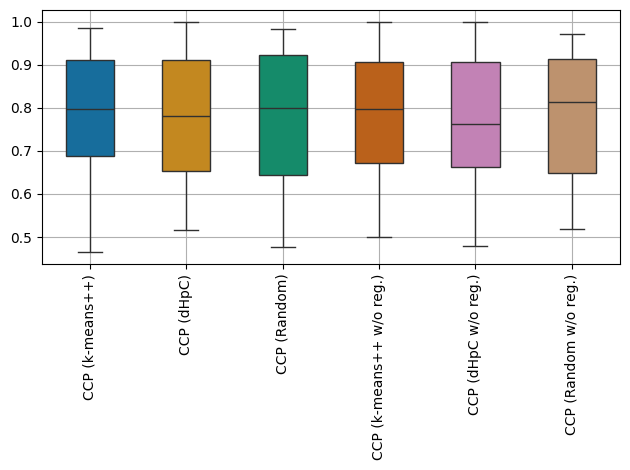

In [ ]:
HoTdiagram(df_F1score[ccp_list], PlotName = "CCP_F1", significance_level = 0.95, NormalizeData=False, Gaussian=False)

Check the file HoTDiagram_CCP_F1.pdf.

Note that the best models are the CCP with k-means++ initialization with or without regularization, with the largest F1-scores and the least variability.

In the following, we compare the MPCL-CCP with k-means++ initialization with the other MPCL models.

Non-parametric Wilcoxon signed-rank test.


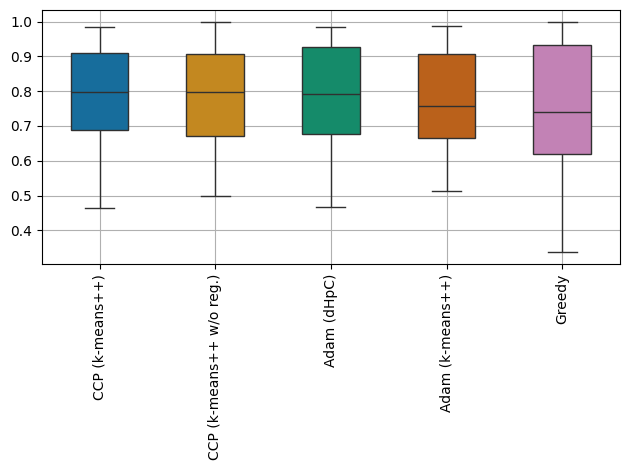

In [ ]:
HoTdiagram(df_F1score[mpcl_list], PlotName = "MPCL_F1", significance_level = 0.95, NormalizeData=False, Gaussian=False)

Check the HoTDiagram_MPCL_F1.pdf file at the Figures folder!

## Compare the training time:

In [ ]:
# Get the list of the MPCL models
mpcl_list = ['CCP (k-means++)',
             'CCP (dHpC)',
             'CCP (Random)',
             'CCP (k-means++ w/o reg.)',
             'CCP (dHpC w/o reg.)',
             'CCP (Random w/o reg.)',
             'Adam (dHpC)',
             'Adam (k-means++)',
             'Greedy'
             #, 'DCCP'
             ]

In [ ]:
df_time = pd.DataFrame({
    'Dataset': df_ccp_kmeanspp['Dataset'],
    'CCP (k-means++)': df_ccp_kmeanspp['Time'],
    'CCP (Random)': df_ccp_random['Time'],
    'CCP (dHpC)': df_ccp_dHpC['Time'],
    'CCP (k-means++ w/o reg.)': df_ccp_kmeanspp_noreg['Time'],
    'CCP (dHpC w/o reg.)': df_ccp_dHpC_noreg['Time'],
    'CCP (Random w/o reg.)': df_ccp_random_noreg['Time'],
    'Adam (k-means++)': df_adam_kmeanspp['Time'],
    'Adam (dHpC)': df_adam_dHpC['Time'],
    'Greedy': df_greedy['Time'],
    # 'DCCP': df_dccp['Time_Taken']
})

df_time

,Dataset,CCP (k-means++),CCP (Random),CCP (dHpC),CCP (k-means++ w/o reg.),CCP (dHpC w/o reg.),CCP (Random w/o reg.),Adam (k-means++),Adam (dHpC),Greedy
0,appendicitis_sim1,0.017876,0.015485,0.013546,0.018102,0.013184,0.015223,6.812213,3.875305,0.000905
1,appendicitis_sim2,0.016612,0.019192,0.008688,0.016704,0.008494,0.017185,8.051769,4.040798,0.000871
2,appendicitis_sim3,0.016843,0.022017,0.007321,0.016918,0.007025,0.021871,6.981539,2.777113,0.000880
3,appendicitis_sim4,0.022136,0.016252,0.025908,0.014417,0.013713,0.018506,4.288720,2.893564,0.000884
4,appendicitis_sim5,0.015421,0.028681,0.023265,0.016316,0.021327,0.015370,8.253845,4.497490,0.000886
...,...,...,...,...,...,...,...,...,...,...
125,wine_recognition_sim6,0.041060,0.023077,0.015204,0.026811,0.015216,0.023032,9.365886,8.344398,0.001125
126,wine_recognition_sim7,0.026237,0.025112,0.022331,0.026824,0.020163,0.024710,9.607700,8.716794,0.000986
127,wine_recognition_sim8,0.030954,0.025092,0.026716,0.022283,0.026913,0.024981,9.785398,6.946848,0.001126
128,wine_recognition_sim9,0.033965,0.025645,0.035109,0.027283,0.015531,0.025861,9.992734,12.745945,0.001105


Non-parametric Wilcoxon signed-rank test.


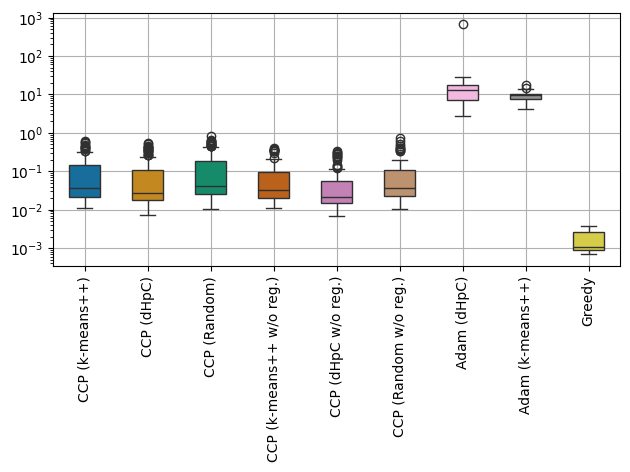

In [ ]:
HoTdiagram(df_time[mpcl_list],
           PlotName = "MPCL_Time",
           significance_level = 0.95,
           NormalizeData=False,
           Gaussian=False,
           LowerAreBest=True,
           UseLogScale=True)

Check the HoTDiagram_MPCL_Time.pdf at the Figures folder.